In [1]:
%matplotlib inline

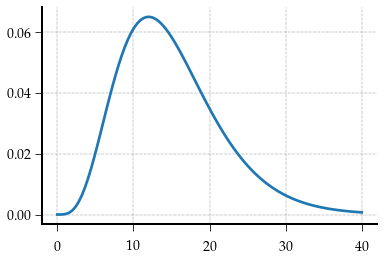

In [2]:
import numpy as np
import scipy.stats as stats 
import matplotlib.pyplot as plt

#define x-axis values
x = np.linspace (0, 40, 100) 

#calculate pdf of Gamma distribution for each x-value
y = stats.gamma.pdf(x, a=5, scale=3)

#create plot of Gamma distribution
plt.plot(x, y)

#display plot
plt.show()

Namespace(blobfile='/data0/gfp-data-aug/Aug/run4a/d20220809_200342_2.dat', verbose=False, calibrate=True, threshold=5.0, eventid=-1, average=True, calibration_file_dir='/srv/gaps/gfp-data/gaps-gfp/TOFsoftware/server/datafiles')
[INFO] <ReadEvent> eof found, returning -1
==> Found 875 events in /data0/gfp-data-aug/Aug/run4a/d20220809_200342_2.dat
16277376
[INFO] There might be at max 878 events in the stream
==> Extracted 874. First evid 170033486, last evid 170034363==> Deserialized 874 blobs! 0 blobs were corrupt
We ran through 0 iterations
We ran through 0 continues



100%|███████████████████████████████████████████████████████████████████████████| 874/874 [00:41<00:00, 21.16it/s]
  waveforms[ch][1] = waveforms[ch][1]/waveforms[ch][0] # average
:warnings:_showwarnmsg:109


==> This has a quad error of 18.30
==> This has a quad error of 0.47 in the selected roi


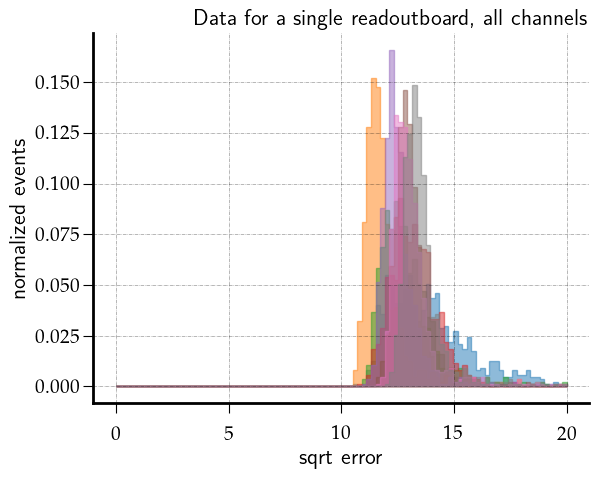

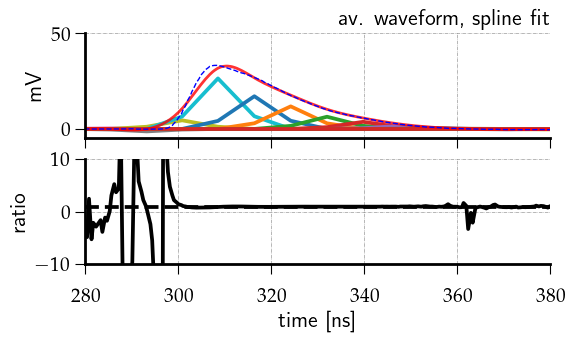

<Figure size 640x480 with 0 Axes>

In [37]:

%run gaps-gfp/TOFsoftware/server/waveform_panopticum.py  --calibration-file-dir /srv/gaps/gfp-data/gaps-gfp/TOFsoftware/server/datafiles --calibrate --average --threshold 5 /data0/gfp-data-aug/Aug/run4a/d20220809_200342_2.dat

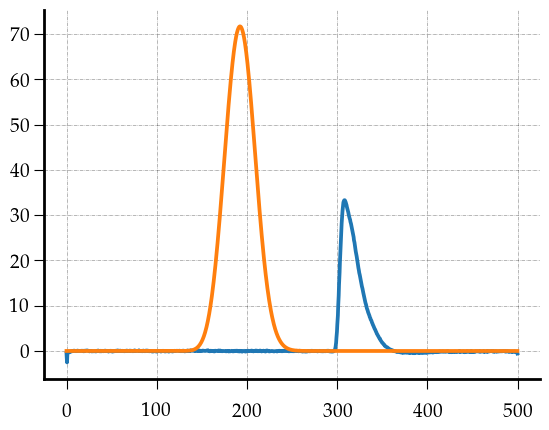

In [66]:
import numpy as np
import scipy.stats as stats 
import matplotlib.pyplot as plt

fig = p.figure()
ax  = fig.gca()

#define x-axis values
x = np.linspace (0, 40, 100) 

def template(a, scale):
    return 2000*stats.gamma.pdf(times[0], a=a, scale=scale)\
            + 1000*stats.gamma.pdf(times[0], a=a-15, scale=scale-0.)
            
#calculate pdf of Gamma distribution for each x-value
y = template(180, 1.1)
ax.plot(times[0],waveforms[0][1])
#create plot of Gamma distribution
ax.plot(times[0], y)

#display plot
plt.show()

In [95]:
import HErmes.fitting as fit

def template(x,\
             amp0, a0, scale0,\
             amp1, a1, scale1,\
             amp2, a2, scale2,\
             amp3, a3, scale3,\
             amp4, a4, scale4,\
             amp5, a5, scale5,\
            ):
    return    amp0*stats.gamma.pdf(x, a=a0, scale=scale0)\
            + amp1*stats.gamma.pdf(x, a=a1, scale=scale1)\
            + amp2*stats.gamma.pdf(x, a=a2, scale=scale2)\
            + amp3*stats.gamma.pdf(x, a=a3, scale=scale3)\
            + amp4*stats.gamma.pdf(x, a=a4, scale=scale4)\
            + amp5*stats.gamma.pdf(x, a=a5, scale=scale5)\

mod = fit.Model(template)
mod.add_data(waveforms[0][1], xs=times[0])
mod.startparams = [2000, 180, 1.1,\
                   1000, 180, 1.0,\
                   500,  175, 1.0,\
                   400,  180, 1.0,\
                   300,  170, 1.0,\
                   200,  165, 1.0,\
                  ]
mod.fit_to_data()
#mod.plot_result()

##########################################


[-0.30163289170095237,
 186.19407812494399,
 1.0554976083439076,
 -1.2758146265147325,
 115.04648602070355,
 0.9199538905117587,
 6.026638529004605,
 146.11446095381172,
 1.0295260496330203,
 -5.13720483990999,
 150.65949692085604,
 1.017559910355053,
 -12.606819661089197,
 171.14659873851764,
 1.0300629061625959,
 12.64800484055869,
 167.59599691624328,
 1.0442872259552516]

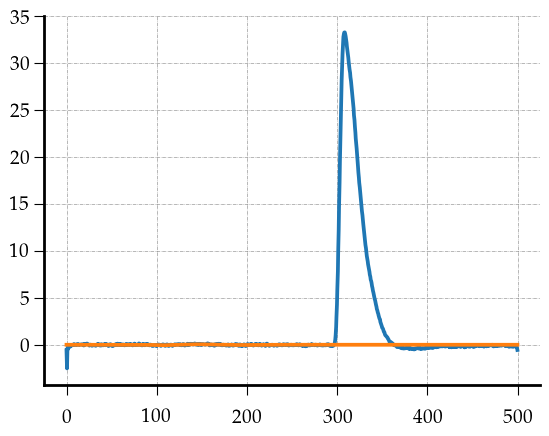

In [94]:
mod.best_fit_params
p.plot(times[0], waveforms[0][1])
p.plot(times[0], template(times[0],*mod.best_fit_params))